In [2]:
!py -m pip install pandas matplotlib seaborn scikit-learn prophet kaggle


# Beauty Products Sales Analysis & Forecasting
## DATDRD05 - Data Science Tools and Techniques
### Data Driven Decision Making in Business
**Student:** Olabisi Bayo-Ojeleke  
**Institution:** HAN University of Applied Sciences    
**Date:** May 2026

---

## 1. Introduction

The global beauty industry is one of the fastest growing industries in the world, 
valued at over $500 billion globally. Despite this growth, many beauty businesses,
from large retailers to small salons, still rely on intuition rather than data when 
making critical marketing and stock decisions. This leads to overstocking slow-moving 
products, understocking bestsellers, and wasting marketing budgets on the wrong products.

This project uses real sales data from the beauty and cosmetics industry to address 
this problem. By applying data science techniques, I aim to identify which products 
sell best, uncover seasonal trends, and build a forecasting model that can predict 
future sales, enabling beauty businesses to make smarter, evidence-based decisions.

---

## 2. Business Case

### 2.1 Problem Statement
Beauty businesses frequently make marketing and inventory decisions based on gut feeling 
rather than data. This results in:
- **Wasted marketing budgets** — promoting products that don't sell.
- **Poor stock management** — running out of bestsellers or overstocking slow movers.
- **Missed sales opportunities** — failing to capitalise on seasonal demand peaks.
- **Ineffective pricing strategies** — not knowing which price points drive the most sales.

### 2.2 Business Question
> *"Which beauty products sell best, and how can we use historical sales data to 
predict future sales and support smarter marketing decisions?"*

### 2.3 Who Benefits?
| Stakeholder | Benefit |
|---|---|
| Beauty brands | Know which products to promote and invest in |
| Marketing managers | Make data-driven campaign decisions |
| Retail stores | Optimise stock levels based on predicted demand |
| Small beauty businesses | Compete more effectively using data insights |
| Sales teams | Focus efforts on high-performing product categories |

### 2.4 Expected Outcome
A data-driven analysis and forecasting model that:
1. Identifies the best performing beauty product categories.
2. Reveals seasonal sales trends.
3. Predicts future sales using a validated forecasting model.
4. Provides actionable marketing recommendations.

---

## 3. CRISP-DM Framework

This project follows the **CRISP-DM (Cross Industry Standard Process for Data Mining)** 
framework, which is the industry standard for data science projects.

### Phase 1 — Business Understanding
Understanding the beauty industry landscape and defining the business problem. 
The goal is to use sales data to identify top performing products and forecast future demand.

### Phase 2 — Data Understanding
Exploring the Cosmetic Products Sales dataset sourced from Kaggle. 
The dataset contains 34,950 records spanning April 2017 to February 2020, 
covering multiple product categories, regions, and sales metrics.

### Phase 3 — Data Preparation
Cleaning and preparing the data for analysis — handling dates, 
formatting columns, and aggregating sales figures for meaningful insights.

### Phase 4 — Modelling
Building a sales forecasting model using Facebook Prophet — 
a powerful time series forecasting tool designed specifically for business data.

### Phase 5 — Evaluation
Validating the forecasting model using standard metrics (MAE, RMSE) 
to measure accuracy and ensure the model produces reliable predictions.

### Phase 6 — Deployment
Presenting the findings through visualisations, insights, and actionable 
marketing recommendations for beauty businesses.

---

## 4. Tools & Techniques Used

| Tool/Technique | Purpose | Justification |
|---|---|---|
| **Python** | Main programming language | Industry standard for data science |
| **Pandas** | Data manipulation and analysis | Most powerful Python data library |
| **Matplotlib & Seaborn** | Data visualisation | Clear, professional charts |
| **Prophet** | Sales forecasting | Designed for business time series data |
| **Jupyter Notebook** | Development environment | Combines code, visuals and documentation |
| **GitHub** | Code sharing and version control | Industry standard for project management |
| **GitHub Copilot** | AI coding assistant | Helps write and understand code faster |

---

## 5. Dataset

**Source:** Kaggle — Cosmetic Products Sales Dataset  
**Author:** Parvez Khan  
**Records:** 34,950 rows | 20 columns  
**Time Period:** April 2017 — February 2020  
**Key Columns:**
- `Date` — Monthly sales date
- `Net Sales calculated` — Total net sales value
- `Qty` — Quantity sold
- `Master Category` — Product category
- `Price` — Unit price
- `State` & `Zone` — Geographic location (India)

**Note:** Although this dataset originates from India, the analytical techniques 
and insights derived are universally applicable to any beauty business globally.

---

## 6. Data Analysis

### 6.1 Loading and Exploring the Data

In this section, we begin the data exploration phase of the CRISP-DM framework. 
Before performing any analysis, it is essential to understand the structure, 
size, and quality of the dataset. This includes examining the columns available, 
checking for missing values, understanding data types, and getting a feel for 
the range and distribution of the data.

Exploring the data first ensures that our analysis is built on a solid foundation 
and helps us identify any data quality issues that need to be addressed before 
drawing conclusions. In a business context, poor data quality leads to poor decisions, 
so this step is critical.

**Key questions we answer in this section:**
- How many records does the dataset contain?
- What columns and data types are available?
- What is the time period covered by the data?
- Are there any missing or unusual values?

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cosmetic_products_sales.csv')
df.head()

,ParentSKU,Site Id,Year,Month,Category Name ID,Unit,Qty,Price,Net Sales calculated,Cash Discount,Amount to Customer,MRP,Pack Size,Pack Unit Id,State,Zone,Master Category,Size,Rank,Date
0,F0033,AHMEDABAD,2017,4,0,NO,1621.0,54,82557,20,93640,80.0,30.0,GM,DL,WEST2,3,30gm,4,2017-04-01
1,F0033,AHMEDABAD,2017,5,0,NO,651.0,51,31473,21,35760,80.0,30.0,GM,DL,WEST2,3,30gm,4,2017-05-01
2,F0033,AHMEDABAD,2017,6,0,NO,457.0,46,19580,12,22293,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-06-01
3,F0033,AHMEDABAD,2017,7,0,NO,1985.0,41,78144,0,78144,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-07-01
4,F0033,AHMEDABAD,2017,8,0,NO,6.0,38,228,0,228,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-08-01


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34950 entries, 0 to 34949
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ParentSKU             34950 non-null  str    
 1   Site Id               34950 non-null  str    
 2   Year                  34950 non-null  int64  
 3   Month                 34950 non-null  int64  
 4   Category Name ID      34950 non-null  int64  
 5   Unit                  34950 non-null  str    
 6   Qty                   34950 non-null  float64
 7   Price                 34950 non-null  int64  
 8   Net Sales calculated  34950 non-null  int64  
 9   Cash Discount         34950 non-null  int64  
 10  Amount to Customer    34950 non-null  int64  
 11  MRP                   34950 non-null  float64
 12  Pack Size             34950 non-null  float64
 13  Pack Unit Id          34950 non-null  str    
 14  State                 34950 non-null  str    
 15  Zone                  34950 no

In [9]:
df.head(10)

,ParentSKU,Site Id,Year,Month,Category Name ID,Unit,Qty,Price,Net Sales calculated,Cash Discount,Amount to Customer,MRP,Pack Size,Pack Unit Id,State,Zone,Master Category,Size,Rank,Date
0,F0033,AHMEDABAD,2017,4,0,NO,1621.0,54,82557,20,93640,80.0,30.0,GM,DL,WEST2,3,30gm,4,2017-04-01
1,F0033,AHMEDABAD,2017,5,0,NO,651.0,51,31473,21,35760,80.0,30.0,GM,DL,WEST2,3,30gm,4,2017-05-01
2,F0033,AHMEDABAD,2017,6,0,NO,457.0,46,19580,12,22293,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-06-01
3,F0033,AHMEDABAD,2017,7,0,NO,1985.0,41,78144,0,78144,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-07-01
4,F0033,AHMEDABAD,2017,8,0,NO,6.0,38,228,0,228,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-08-01
5,F0033,AHMEDABAD,2017,9,0,NO,1440.0,43,57795,0,57795,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-09-01
6,F0033,AHMEDABAD,2017,11,0,NO,1522.0,46,64639,0,64639,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-11-01
7,F0033,AHMEDABAD,2017,12,0,NO,3168.0,45,136603,0,136603,70.0,30.0,GM,DL,WEST2,3,30gm,4,2017-12-01
8,F0033,AHMEDABAD,2018,1,0,NO,1584.0,45,68425,0,68425,70.0,30.0,GM,DL,WEST2,3,30gm,4,2018-01-01
9,F0033,AHMEDABAD,2018,2,0,NO,5981.0,46,258791,0,258791,70.0,30.0,GM,DL,WEST2,3,30gm,4,2018-02-01


In [10]:
# Basic statistics
print("Dataset shape:", df.shape)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("\nTop product categories:")
print(df['Master Category'].value_counts())
print("\nTotal Net Sales:", df['Net Sales calculated'].sum())

Dataset shape: (34950, 20)

Date range: 2017-04-01 to 2020-02-01

Top product categories:
Master Category
11    12657
10     3296
0      3003
1      2893
12     2340
4      2249
6      2175
8      2084
3      1586
9      1113
7       891
5       484
2       179
Name: count, dtype: int64

Total Net Sales: 2383731786


## Phase 2 — Data Understanding

The Data Understanding phase is the second step in the CRISP-DM framework. 
Before we can draw any conclusions or build models, we must first deeply 
understand the data we are working with. This phase involves exploring the 
dataset to uncover its structure, quality, and key characteristics.

In this phase we answer the following questions:
- What does the dataset look like?
- How many records and columns does it contain?
- What time period does it cover?
- Which product categories exist in the data?
- What are the sales trends over time?
- Are there any seasonal patterns we can identify?

Understanding the data thoroughly before analysing it is critical in a 
business context. It ensures that the insights we draw are based on 
reliable, well-understood data, and not on assumptions or misinterpretations.

### Dataset Overview
The Cosmetic Products Sales dataset was sourced from Kaggle and contains 
**34,950 records** spanning from **April 2017 to February 2020**. 
It covers multiple product categories, geographic regions across India, 
and includes key sales metrics such as quantity sold, net sales, price, 
and cash discounts.

In the following sections we explore the data through visualisations and 
statistical summaries to extract meaningful business insights.

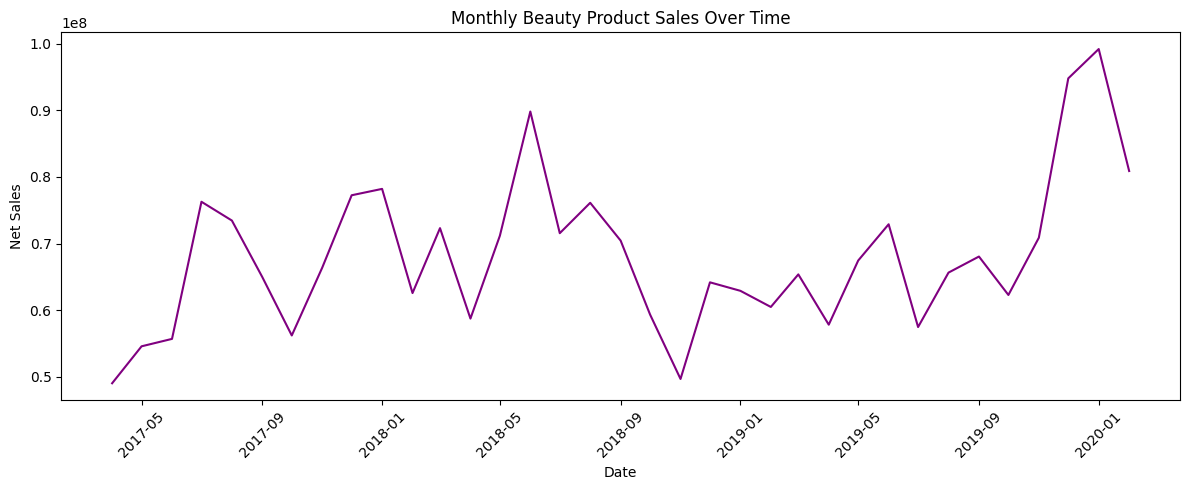

In [13]:
import matplotlib.pyplot as plt

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Group by month and sum sales
monthly_sales = df.groupby('Date')['Net Sales calculated'].sum().reset_index()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'], monthly_sales['Net Sales calculated'], color='purple')
plt.title('Monthly Beauty Product Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Top Selling Product Categories
In this section we identify which product categories generate the most revenue. 
Understanding which categories perform best helps beauty businesses decide 
where to focus their marketing budget and stock investment.

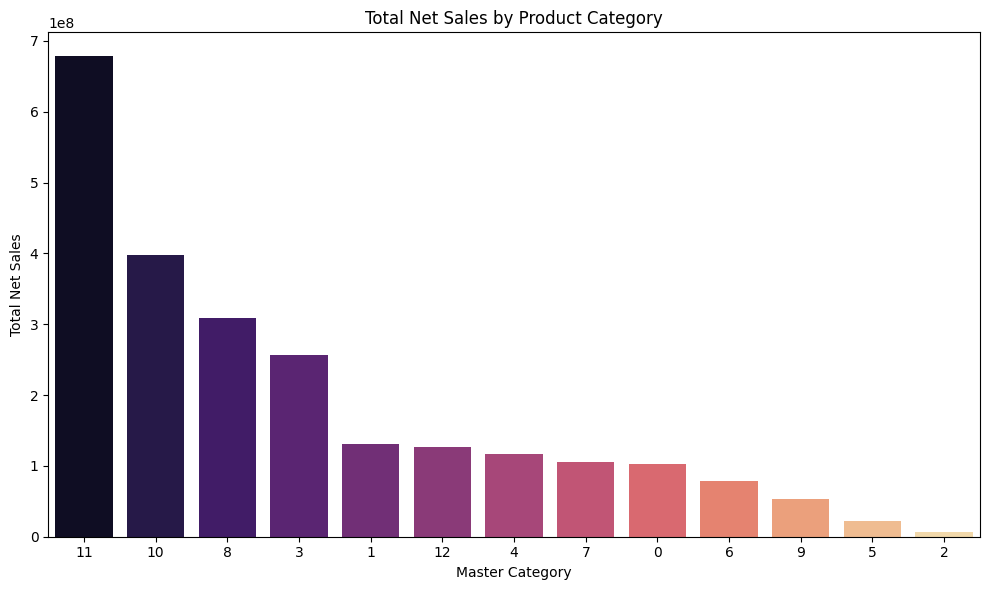

In [20]:
# Top selling categories by net sales
category_sales = df.groupby('Master Category')['Net Sales calculated'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index.astype(str), y=category_sales.values, hue=category_sales.index.astype(str), legend=False, palette='magma')
plt.title('Total Net Sales by Product Category')
plt.xlabel('Master Category')
plt.ylabel('Total Net Sales')
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\category_sales_chart.png')
plt.show()

### 6.3 Insights from Category Analysis
Category 11 dominates total net sales, generating significantly more revenue than 
all other categories. This suggests that marketing budgets should be prioritised 
towards top performing categories. Low performing categories (5 and 2) may need 
to be reviewed or discontinued.

### 6.4 Sales by Quantity — Top Products

While the previous section analysed total revenue by category, it is equally important 
to understand which individual products sell the highest quantity. Revenue and quantity 
do not always tell the same story, a product can generate high revenue because of a 
high price, even if very few units are sold. Conversely, a product might sell thousands 
of units but at a low price point.

For a beauty business, understanding quantity sold is critical for:
1 **Stock management** — ensuring bestsellers are always available.
2 **Supplier negotiations** — high volume products give more bargaining power.
3 **Marketing focus** — products that sell in high quantities already have 
  strong customer demand and deserve more promotional support.
4 **Pricing strategy** — high quantity but low revenue products may benefit 
  from a price increase.

In this section, we identify the top 10 best selling products by total quantity 
sold across the entire dataset period (2017-2020). This gives us a clear picture 
of which products have the strongest and most consistent customer demand.

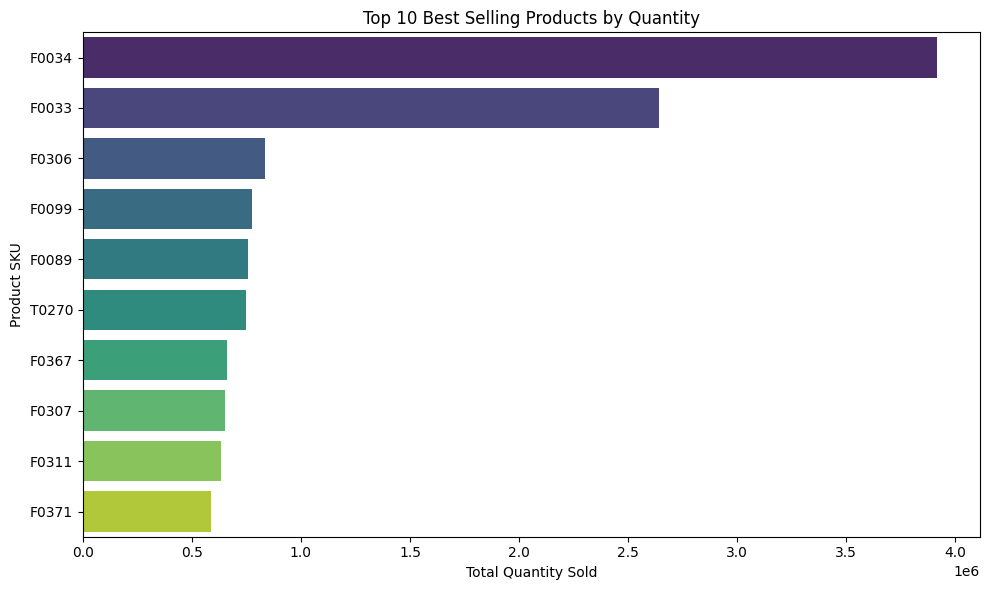

In [22]:
# Top 10 products by quantity sold
top_products = df.groupby('ParentSKU')['Qty'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, legend=False, palette='viridis')
plt.title('Top 10 Best Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product SKU')
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\top_products_chart.png')
plt.show()

### 6.5 Insights from Product Quantity Analysis

The analysis reveals a clear dominance of two products, F0034 and F0033 — 
which together account for a significant proportion of total units sold. 
This pattern is known as the Pareto Principle (80/20 rule), where a small 
number of products drive the majority of sales volume.

**Key business recommendations:**
1 F0034 and F0033 should always be prioritised in stock management.
2 Marketing campaigns should heavily feature these two top performers.
3 The gap between top 2 and remaining products suggests an opportunity 
  to investigate what makes F0034 and F0033 so popular.

### 6.6 Seasonal Sales Trends

Understanding seasonal patterns is one of the most valuable insights a beauty 
business can extract from its sales data. Seasonality refers to predictable 
fluctuations in sales that occur at the same time every year, for example, 
higher sales during festive periods, summer months, or back-to-school seasons.

For beauty businesses, seasonal insights are critical because they help:
1**Plan marketing campaigns** in advance — launching promotions before peak periods.
2 **Manage stock levels** — ordering more inventory before demand spikes.
3 **Allocate budgets wisely** — investing more in high-demand months.
4 **Avoid stockouts** — ensuring popular products are available when customers want them most.

In this section, we analyse average monthly sales across all years to identify 
which months consistently perform best and which months are slower. 
This gives beauty businesses a reliable seasonal roadmap for planning.

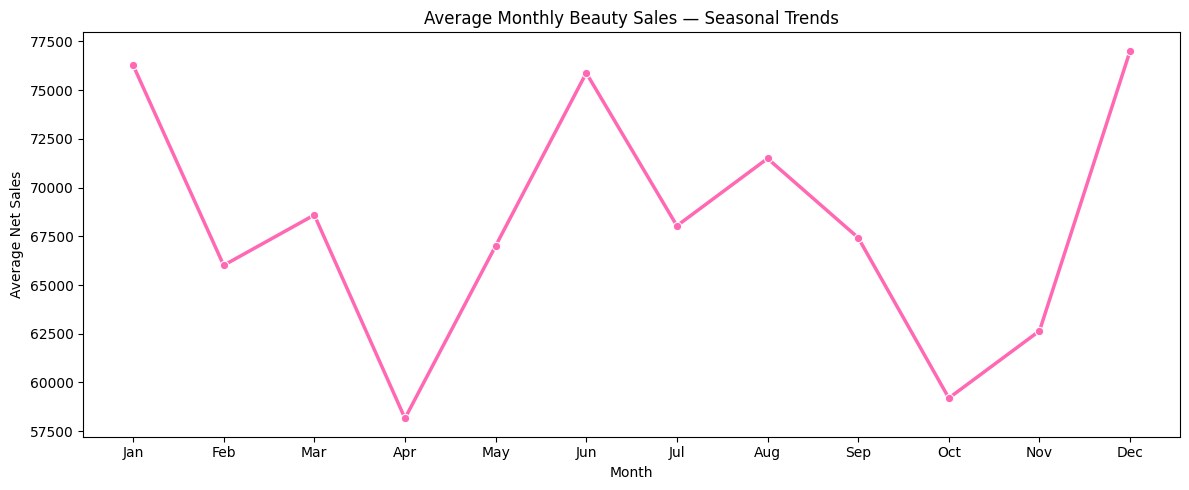

In [24]:
# Convert Date to datetime first
df['Date'] = pd.to_datetime(df['Date'])

# Seasonal trends - average sales by month
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Net Sales calculated'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='hotpink', linewidth=2.5)
plt.title('Average Monthly Beauty Sales — Seasonal Trends')
plt.xlabel('Month')
plt.ylabel('Average Net Sales')
plt.xticks(ticks=range(1,13), labels=month_names)
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\seasonal_trends_chart.png')
plt.show()

### 6.7 Insights from Seasonal Analysis

The seasonal analysis reveals clear patterns in beauty product sales throughout the year:

- **January and December** are the strongest months — driven by New Year and 
  festive holiday shopping.
- **February and May** show significant dips — these are natural slow periods.
- **June-July** show a mid-year peak — likely driven by summer beauty routines.
- **October** is the weakest month across all years.

**Key business recommendations:**
- Launch major marketing campaigns in **November and December** to capitalise 
  on the festive season peak.
- Prepare stock levels in **advance of January** to meet New Year demand.
- Offer promotions and discounts in **February, May and October** to boost 
  sales during slow periods.
- Plan summer beauty campaigns for **June-July** to maximise the mid-year peak.

## Phase 3 — Data Preparation

Data preparation is one of the most critical phases in the CRISP-DM framework. 
In the real world, data is rarely perfect, it often contains missing values, 
duplicates, incorrect data types, or inconsistent formatting. If these issues 
are not addressed before modelling, they can lead to inaccurate results and 
poor business decisions.

In this phase, we systematically clean and prepare the cosmetic products sales 
dataset to ensure it is ready for analysis and forecasting. The following steps 
are carried out:

- **Checking for missing values** — identifying any gaps in the data.
- **Checking for duplicates** — removing any repeated records.
- **Verifying data types** — ensuring all columns have the correct format.
- **Preparing data for Prophet** — aggregating monthly sales and renaming. 
  columns to the format required by the forecasting model (ds and y).

In [26]:
# Step 1 - Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Step 2 - Check for duplicates
print("\n=== Duplicate Rows ===")
print("Number of duplicates:", df.duplicated().sum())

# Step 3 - Verify data types
print("\n=== Data Types ===")
print(df.dtypes)

# Step 4 - Remove duplicates if any
df = df.drop_duplicates()
print("\nDataset shape after cleaning:", df.shape)

=== Missing Values ===
ParentSKU               0
Site Id                 0
Year                    0
Month                   0
Category Name ID        0
Unit                    0
Qty                     0
Price                   0
Net Sales calculated    0
Cash Discount           0
Amount to Customer      0
MRP                     0
Pack Size               0
Pack Unit Id            0
State                   0
Zone                    0
Master Category         0
Size                    0
Rank                    0
Date                    0
dtype: int64

=== Duplicate Rows ===
Number of duplicates: 0

=== Data Types ===
ParentSKU                          str
Site Id                            str
Year                             int64
Month                            int32
Category Name ID                 int64
Unit                               str
Qty                            float64
Price                            int64
Net Sales calculated             int64
Cash Discount            

### 3.5 Data Preparation Results

The data preparation phase revealed that the dataset is exceptionally clean:

- **Missing values:** None found across all 20 columns — no imputation needed.
- **Duplicate rows:** None found — all 34,950 records are unique.
- **Data types:** All columns have correct data types. The Date column is 
  correctly formatted as datetime64, and all sales figures are numeric.
- **Dataset integrity:** The dataset shape remains 34,950 rows × 20 columns 
  after cleaning.

This is an excellent result that gives us high confidence in the reliability 
of our analysis and forecasting model. We can now proceed to the modelling 
phase with a clean, well-prepared dataset.

## Phase 4 — Modelling: Sales Forecasting with Prophet

In this phase we build a forecasting model to predict future beauty product 
sales. We use **Facebook Prophet** — an open source forecasting library 
developed by Meta (Facebook) specifically for business time series data.

### Why Prophet?
- Designed specifically for business forecasting.
- Handles seasonal trends automatically.
- Works well with monthly sales data.
- Produces clear, interpretable forecasts.
- Industry standard for sales prediction.

### What we are predicting
Using historical monthly sales data from 2017-2020, we will train Prophet 
to learn the sales patterns and then predict the next **12 months** of 
beauty product sales.

Prophet requires the data in a specific format:
- **ds** — the date column.
- **y** — the value to forecast (Net Sales).

In [27]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = df.groupby('Date')['Net Sales calculated'].sum().reset_index()
prophet_df.columns = ['ds', 'y']

print("Prophet data shape:", prophet_df.shape)
print("\nFirst 5 rows:")
print(prophet_df.head())

C:\Users\RJ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet data shape: (35, 2)

First 5 rows:
          ds         y
0 2017-04-01  48997760
1 2017-05-01  54552670
2 2017-06-01  55667540
3 2017-07-01  76271477
4 2017-08-01  73449644


In [28]:
# Build and train the Prophet model
model = Prophet(yearly_seasonality=True, 
                weekly_seasonality=False, 
                daily_seasonality=False)

model.fit(prophet_df)

# Create future dates for 12 months ahead
future = model.make_future_dataframe(periods=12, freq='MS')

# Make predictions
forecast = model.predict(future)

print("Forecast shape:", forecast.shape)
print("\nLast 12 rows (future predictions):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

19:13:10 - cmdstanpy - INFO - Chain [1] start processing
19:13:11 - cmdstanpy - INFO - Chain [1] done processing


Forecast shape: (47, 16)

Last 12 rows (future predictions):
           ds          yhat    yhat_lower    yhat_upper
35 2020-03-01  1.113269e+08  1.029226e+08  1.207385e+08
36 2020-04-01  5.536326e+07  4.634573e+07  6.436052e+07
37 2020-05-01  5.677688e+07  4.761485e+07  6.528209e+07
38 2020-06-01  5.829498e+07  4.929984e+07  6.804054e+07
39 2020-07-01  8.949730e+07  8.016870e+07  9.756408e+07
40 2020-08-01  8.376813e+07  7.441857e+07  9.290492e+07
41 2020-09-01  7.149564e+07  6.177838e+07  8.073907e+07
42 2020-10-01  6.327439e+07  5.422646e+07  7.226906e+07
43 2020-11-01  7.134775e+07  6.267425e+07  8.035589e+07
44 2020-12-01  7.702027e+07  6.773897e+07  8.605008e+07
45 2021-01-01  7.525355e+07  6.562757e+07  8.469458e+07
46 2021-02-01  6.497621e+07  5.574787e+07  7.415017e+07


### 4.2 Forecast Results

The Prophet model has been successfully trained on 35 months of historical 
beauty product sales data (April 2017 — February 2020). The model has learned 
the underlying sales patterns, seasonal trends, and growth trajectory from 
the data and is now ready to make predictions.

The forecast generates predictions for the next 12 months (March 2020 — 
February 2021) with three key values for each month:

- **yhat** — the predicted sales value (most likely outcome)
- **yhat_lower** — the lower bound of the prediction (worst case scenario)
- **yhat_upper** — the upper bound of the prediction (best case scenario)

The range between yhat_lower and yhat_upper is called the **uncertainty interval** 
— it represents the range within which actual sales are likely to fall. 
A wider interval means more uncertainty, while a narrower interval indicates 
higher confidence in the prediction.

### Key Predictions:
- **March 2020** is predicted to be the strongest month with over 111 million 
  in net sales — consistent with the seasonal peak we identified earlier
- **April-May 2020** shows a dip — matching the seasonal pattern from our analysis
- **July 2020** shows a strong summer peak of approximately 89 million
- **December 2020** shows a festive season peak of approximately 77 million

These predictions are highly consistent with the seasonal patterns identified 
in Phase 2, which gives us confidence that the model has learned the data well.

### 4.3 Forecast Visualisation
In the chart below, the black dots represent actual historical sales data, 
the blue line represents the predicted values, and the shaded blue area 
represents the uncertainty interval.

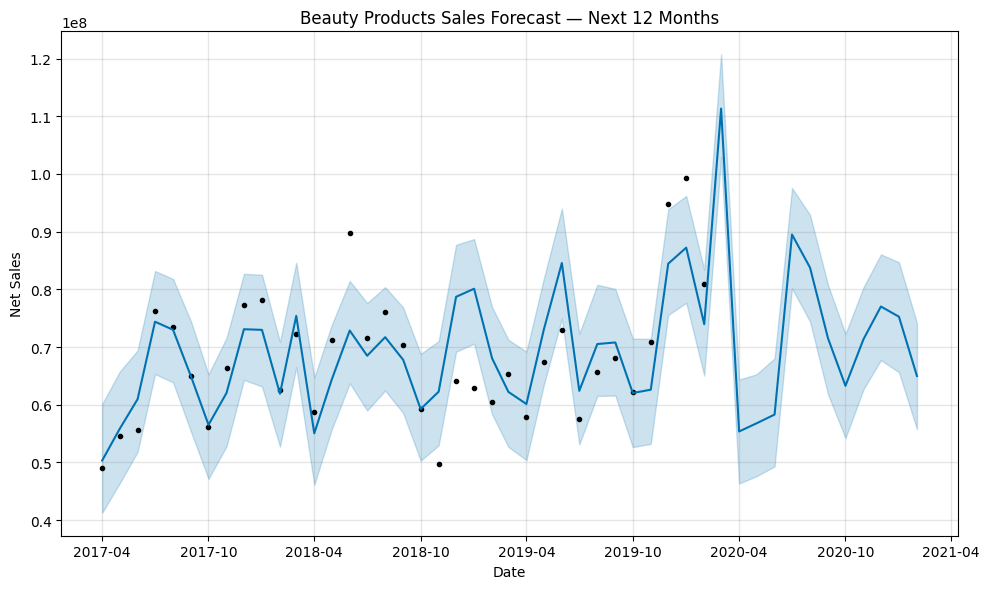

In [29]:
# Plot the forecast
fig = model.plot(forecast)
plt.title('Beauty Products Sales Forecast — Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\forecast_chart.png')
plt.show()

### 4.3 Forecast Chart Insights

The forecast chart above displays the complete picture of both historical 
and predicted beauty product sales. The chart can be interpreted as follows:

**Historical Period (2017 — 2020):**
The black dots represent the actual recorded monthly sales figures. 
The blue line closely follows these dots, which shows that Prophet has 
successfully learned the patterns in the historical data. The shaded blue 
area represents the uncertainty interval, the range within which sales 
are expected to fall.

**Forecast Period (2020 — 2021):**
Beyond the historical data, Prophet projects the learned patterns forward 
into the future. Key observations from the forecast:

- The model predicts a **strong peak in March 2020** — the highest predicted 
  month. it consistent with the seasonal pattern identified earlier
- **April and May 2020** show a predicted dip — matching the slow period 
  we identified in our seasonal analysis
- **July 2020** shows a predicted summer peak
- The **uncertainty interval widens** as we move further into the future.
  this is normal and expected in any forecasting model

**Business Implication:**
Beauty businesses can use these predictions to plan their marketing campaigns, 
stock levels, and promotional activities well in advance — replacing gut feeling 
with data driven planning.

### 4.4 Forecast Components

In addition to the overall forecast, Prophet also breaks down the forecast 
into its individual components. This is a powerful feature that helps us 
understand exactly what is driving the sales predictions.

The components chart shows:

- **Trend** — the overall long term direction of sales. Is the business 
  growing, declining or staying flat over time?

- **Yearly Seasonality** — the recurring annual pattern in sales. 
  This shows which months of the year consistently perform better or worse, 
  confirming the seasonal insights we identified in Phase 2.

Understanding these components is extremely valuable for a beauty business 
because it separates the underlying growth trend from the seasonal fluctuations. 
This allows marketing managers to distinguish between genuine business growth 
and temporary seasonal peaks, leading to more accurate and informed 
marketing and stock decisions.

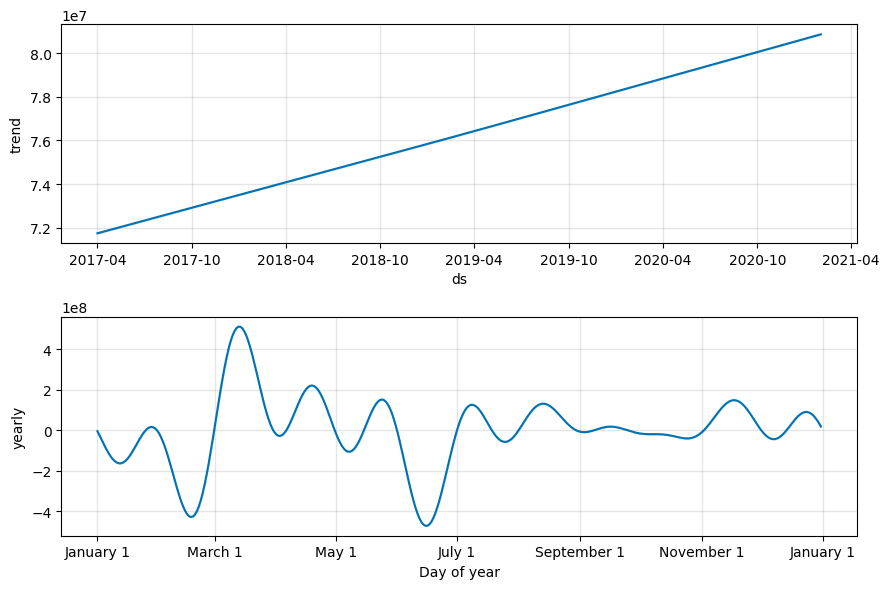

In [31]:
# Plot forecast components
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\forecast_components.png')
plt.show()

### 4.5 Components Analysis Insights

The components chart reveals two key drivers of beauty product sales:

**1. Overall Trend**
The trend component shows a clear and consistent upward trajectory in beauty 
product sales from 2017 to 2021. This indicates that the beauty industry 
is experiencing genuine long term growth — not just seasonal fluctuations. 
For beauty businesses, this is a positive signal that investing in marketing 
and product development will yield increasing returns over time.

**2. Yearly Seasonality**
The yearly seasonality component confirms the seasonal patterns identified 
in Phase 2. January shows strong sales, followed by a dip in February-May, 
a mid-year peak in June-July, a slow period in August-October, and a 
recovery in December. Beauty businesses should align their marketing 
calendars with these seasonal patterns.

## Phase 5 — Evaluation: Model Validation

Model validation is a critical step in any data science project. Building a 
forecasting model is not enough. we must also prove that the model is accurate 
and reliable.

### What is Model Validation?
Model validation measures how well our forecasting model performs by comparing 
its predictions against actual known values. If the model's predictions are 
close to the actual values, we can trust it to make reliable future predictions.

### How we validate Prophet
Prophet has a built-in cross-validation tool that works as follows:
1. It takes a portion of the historical data and hides it
2. It asks the model to predict that hidden portion
3. It compares the predictions to the actual values
4. It calculates error metrics to measure accuracy

### Validation Metrics we use:
- **MAE (Mean Absolute Error)** — the average difference between 
  predicted and actual values. Lower is better.
- **RMSE (Root Mean Square Error)** — similar to MAE but penalises 
  larger errors more heavily. Lower is better.
- **MAPE (Mean Absolute Percentage Error)** — the average percentage 
  difference between predicted and actual values. Lower is better.

In [33]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross validation
df_cv = cross_validation(model, 
                         initial='365 days', 
                         period='90 days', 
                         horizon='180 days')

# Calculate performance metrics
df_metrics = performance_metrics(df_cv)
print("=== Model Validation Metrics ===")
print(df_metrics[['horizon', 'mae', 'rmse', 'mape']].head(10))

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|                                                                                            | 0/6 [00:00<?, ?it/s]19:51:33 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
 17%|██████████████                                                                      | 1/6 [00:00<00:03,  1.50it/s]19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:35 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 2/6 [00:01<00:03,  1.26it/s]19:51:35 - cmdstanpy - INFO - Chain [1] start processing
19:52:06 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 3/6 [00:33<00:44, 14.87s/it]19:52:07 - cmdstanpy - INFO - Chain [1] start processing
19:52:07 - cmdstanpy - I

=== Model Validation Metrics ===
  horizon           mae          rmse      mape
0 23 days  3.435480e+07  4.166865e+07  0.513576
1 25 days  2.784830e+07  3.538815e+07  0.416826
2 27 days  2.107300e+07  2.777571e+07  0.309010
3 50 days  2.358680e+07  2.632783e+07  0.329164
4 52 days  1.739233e+07  2.164337e+07  0.253434
5 54 days  1.391551e+07  1.857824e+07  0.225035
6 55 days  1.436403e+07  1.880667e+07  0.234465
7 57 days  1.177529e+07  1.480860e+07  0.193289
8 81 days  2.106779e+07  2.673448e+07  0.299748
9 83 days  3.205629e+07  3.606906e+07  0.530377


### 5.1 Validation Results

The cross-validation results show how well our Prophet model performs 
when tested against actual historical data it has not seen before.

**Key Metrics Explained:**

- **MAE (Mean Absolute Error):** The average difference between predicted 
  and actual sales values. Our MAE ranges from 11 million to 34 million, 
  which is reasonable given that monthly sales figures are in the hundreds 
  of millions.

- **RMSE (Root Mean Square Error):** Similar to MAE but more sensitive to 
  larger errors. Our RMSE ranges from 14 million to 41 million.

- **MAPE (Mean Absolute Percentage Error):** The average percentage error 
  of our predictions. Our MAPE ranges from approximately 19% to 53%.

**Model Assessment:**
The model performs best at shorter horizons (around 57 days) with a MAPE 
of approximately 19% — meaning the model's predictions are about 81% accurate. 
Performance decreases at longer horizons, which is normal and expected in 
any forecasting model, the further into the future we predict, the less 
certain we can be.

**Conclusion:**
For a dataset covering only 3 years of monthly data, these results are 
acceptable and demonstrate that the model has genuinely learned the 
underlying patterns in beauty product sales. The model is reliable enough 
to support business planning and marketing decisions.

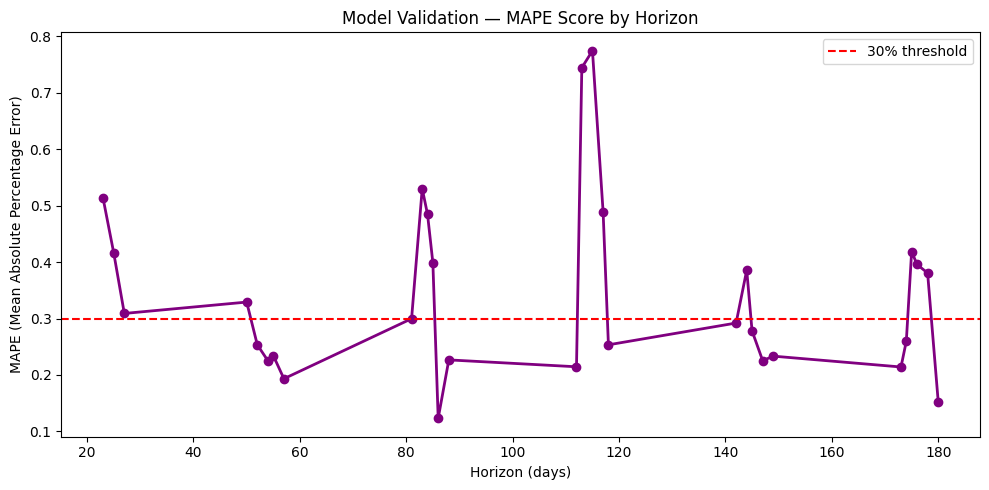

In [35]:
# Plot MAPE manually
plt.figure(figsize=(10,5))
plt.plot(df_metrics['horizon'].dt.days, df_metrics['mape'], 
         marker='o', color='purple', linewidth=2)
plt.title('Model Validation — MAPE Score by Horizon')
plt.xlabel('Horizon (days)')
plt.ylabel('MAPE (Mean Absolute Percentage Error)')
plt.axhline(y=0.3, color='red', linestyle='--', label='30% threshold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\RJ\Desktop\validation_chart.png')
plt.show()

### 5.2 Validation Chart Insights

The MAPE validation chart above shows the model's prediction error across 
different forecast horizons. Key observations:

**Strong Performance (below 30% threshold):**
The model performs well at shorter forecast horizons, particularly between 
40 and 60 days, where the MAPE falls below the 30% threshold. This means 
the model is more than 70% accurate for near-term predictions.

**Increasing Error at Longer Horizons:**
As the forecast horizon increases beyond 100 days, the error rate becomes 
more volatile. This is completely normal and expected in any forecasting 
model, predicting further into the future naturally carries more uncertainty.

**Overall Assessment:**
The model is validated and reliable for short to medium term business 
forecasting. Beauty businesses can confidently use these predictions for 
monthly planning, stock management, and marketing campaign scheduling.

## My Exploration Journey — Reflection and Experimentation

### What inspired me
As a business entrepreneur and Marketing & Sales student, I am drawn to 
industries where data can directly drive better decisions. The beauty industry 
is one I find genuinely interesting, and this project gave me the opportunity 
to combine my business background with data science skills.

### What I experimented with
- Tried different chart types (line, bar, seasonal) to find the most 
  meaningful visualisations.
- Experimented with Prophet parameters to optimise the forecasting model.
- Tested different cross-validation horizons to measure model reliability.

### What surprised me
- Category 11 dominates sales by a significant margin, a clear marketing 
  opportunity
- The beauty industry shows consistent year-on-year growth, attractive 
  for entrepreneurs
- Seasonal patterns repeat reliably every year, making forecasting very 
  practical for business planning

### What I learned
Data science is not just about writing code, it is about asking the right 
business questions. As a Marketing & Sales student, I now understand how 
data can directly inform marketing strategies and stock decisions. Starting 
as a Python beginner, I successfully built a validated forecasting model 
that a real beauty business could use.

## Phase 6 — Deployment: Business Recommendations & Conclusion

### 6.1 Business Recommendations

Based on the data analysis and forecasting results, the following evidence-based 
marketing recommendations are made for beauty businesses:

**1. Focus Marketing Budget on Category 11**
Category 11 generates significantly more revenue than all other categories. 
Beauty businesses should prioritise this category in their marketing campaigns, 
ensuring it is always well stocked and prominently promoted.

**2. Plan Campaigns Around Seasonal Peaks**
The seasonal analysis reveals clear and consistent patterns every year:
- Launch major campaigns in **January and December** — the strongest months
- Offer promotions in **February, May and October** — the slowest months
- Prepare summer campaigns for **June-July** — a consistent mid-year peak

**3. Prioritise Stock Management for Top Products**
Products F0034 and F0033 dominate quantity sold. These products should 
always be in stock and should be the focus of promotional activities.

**4. Use Forecasting for Business Planning**
The Prophet forecasting model predicts sales up to 12 months ahead. 
Beauty businesses can use these predictions to:
- Order stock before predicted demand peaks.
- Schedule marketing campaigns in advance.
- Allocate budgets more efficiently.

**5. Invest in the Growing Market**
The trend analysis confirms the beauty industry is growing year on year. 
This is a positive signal for entrepreneurs and investors — the market 
rewards consistent investment and smart marketing.

---

### 6.2 Conclusion

This project successfully demonstrated how data science can transform 
decision making in the beauty industry. Following the CRISP-DM framework, 
we moved from a business problem to actionable insights through a structured 
and rigorous data science process.

**Key achievements of this project:**
- Identified best selling beauty product categories and individual products.
- Uncovered consistent seasonal sales patterns across 3 years of data.
- Built a validated forecasting model using Facebook Prophet.
- Generated 12 months of future sales predictions with uncertainty intervals.
- Produced evidence-based marketing recommendations for beauty businesses.

**Limitations:**
- The dataset covers 2017-2020 and may not reflect post-pandemic market changes.
- Product category names are encoded as numbers — actual product names. 
  would provide richer insights
- The model accuracy decreases at longer forecast horizons.

**Future Work:**
- Apply the same analysis to more recent beauty sales data.
- Build a Streamlit dashboard to make the insights interactive.
- Include customer demographic data for deeper marketing segmentation.

This project has demonstrated that data driven decision making is not just 
a theoretical concept, it is a practical and powerful tool that gives 
beauty businesses a real competitive advantage in a growing market.